# Structures vs BC-augment-only: evaluation on the 4 held-out generalization scenarios
Compares two models on the same 4 held-out structure scenarios:
- **structures_***: trained on `ahr_river_v03_marg_structures_bcaugment_additionalsrc_velocity_100m_warmstart_multisim` (12 levee/dam scenarios + 20 BC-augmentation events, `config_best_sweep_structures_bcaugment.yaml`, mesh = `template_100m_structures.pkl`).
- **bcaugment_only_***: trained on `ahr_river_v03_marg_bcaugment_additionalsrc_velocity_100m_warmstart_multisim` (the 20 BC-augmentation events only, no structures ever seen, `config_best_sweep_bcaugment.yaml`, mesh = `template_100m.pkl`).

None of the 4 scenarios below were in either training mix.

| tag | tests generalization to... |
|---|---|
| `bothbanks_dz10m` | unseen **magnitude** (2x beyond the highest trained levee crest, dz5m) |
| `gap_dz5m` | unseen **structural footprint** (a breach, same site family as the trained levees) |
| `thin_dam2_dz15m` | unseen **location** for the thin-dam mechanism (~3-4 km from the trained crossing), same crest height as training |
| `thin_dam2_dz20m` | unseen **location**, other trained crest height |

Each of these has real SFINCS ground truth.

In [9]:
import sys, os

# Resolve the repo root robustly (works in VS Code and nbconvert, any start cwd)
try:
    REPO_ROOT = os.path.abspath(os.path.join(os.path.dirname(__vsc_ipynb_file__), '..'))
except NameError:
    _here = os.getcwd()
    REPO_ROOT = _here if os.path.isdir(os.path.join(_here, 'database')) \
                else os.path.abspath(os.path.join(_here, '..'))
assert os.path.isdir(os.path.join(REPO_ROOT, 'database')), f'Not the repo root: {REPO_ROOT}'
os.chdir(REPO_ROOT)
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import torch
import wandb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from utils.load import read_config
from utils.miscellaneous import get_model, fix_dict_in_config
from utils.dataset import create_model_dataset, get_temporal_test_dataset_parameters, to_temporal_dataset
from utils.visualization import PlotRollout
from training.train import LightningTrainer

torch.backends.cudnn.deterministic = True
torch.set_float32_matmul_precision('high')
print('Repo root:', REPO_ROOT)

Repo root: c:\Users\marrocol\OneDrive - Stichting Deltares\Documents\mSWE-GNN\mSWE-GNN_marg\mSWE-GNN_marg


## Config

In [10]:
# Each model carries its OWN config, used to fit ITS OWN scalers (train_dataset_name
# stays each config's real training set) - architecture itself is auto-detected per
# checkpoint anyway, so the config only matters for scalers/lr_info/trainer_options.
MODELS = [
    {'name': 'structures_best_valloss',     'config': 'config_best_sweep_structures_bcaugment_weircrest.yaml',
     'checkpoint': os.path.join(REPO_ROOT, 'results', 'best_sweep_structures_bcaugment_weircrest.h5')},
    {'name': 'structures_bestCSI',          'config': 'config_best_sweep_structures_bcaugment_weircrest.yaml',
     'checkpoint': os.path.join(REPO_ROOT, 'results', 'best_sweep_structures_bcaugment_weircrest_bestCSI.h5')},
    {'name': 'bcaugment_only_best_valloss', 'config': 'config_best_sweep_bcaugment.yaml',
     'checkpoint': os.path.join(REPO_ROOT, 'results', 'best_sweep_bcaugment.h5')},
    {'name': 'bcaugment_only_bestCSI',      'config': 'config_best_sweep_bcaugment.yaml',
     'checkpoint': os.path.join(REPO_ROOT, 'results', 'best_sweep_bcaugment_bestCSI.h5')},
]

# tag -> (dataset name, description)
TEST_SCENARIOS = {
    'bothbanks_dz10m': ('ahr_river_v03_marg_structures_bothbanks_dz10m_additionalsrc_velocity_100m_warmstart',
                         'unseen magnitude (2x beyond trained crest height)'),
    'gap_dz5m':        ('ahr_river_v03_marg_structures_gap_dz5m_additionalsrc_velocity_100m_warmstart',
                         'unseen structural footprint (breach)'),
    'thin_dam2_dz15m': ('ahr_river_v03_marg_structures_thin_dam2_dz15m_additionalsrc_velocity_100m_warmstart',
                         'unseen location (thin dam, same crest height)'),
    'thin_dam2_dz20m': ('ahr_river_v03_marg_structures_thin_dam2_dz20m_additionalsrc_velocity_100m_warmstart',
                         'unseen location (thin dam, other crest height)'),
}

print('--- checkpoints ---')
for m in MODELS:
    exists = os.path.exists(m['checkpoint'])
    size = f"{os.path.getsize(m['checkpoint'])/1e6:.1f} MB" if exists else 'MISSING'
    print(f"{m['name']:<24} config={m['config']:<48} exists={exists!s:<6} {size:>10}")

print('\n--- test scenario pkls ---')
for tag, (name, desc) in TEST_SCENARIOS.items():
    p = os.path.join(REPO_ROOT, 'database', 'datasets', 'test', name + '.pkl')
    print(f"{tag:<18} exists={os.path.exists(p)!s:<6} ({desc})")

--- checkpoints ---
structures_best_valloss  config=config_best_sweep_structures_bcaugment_weircrest.yaml exists=True       2.5 MB
structures_bestCSI       config=config_best_sweep_structures_bcaugment_weircrest.yaml exists=True       2.5 MB
bcaugment_only_best_valloss config=config_best_sweep_bcaugment.yaml                 exists=True       2.5 MB
bcaugment_only_bestCSI   config=config_best_sweep_bcaugment.yaml                 exists=True       2.5 MB

--- test scenario pkls ---
bothbanks_dz10m    exists=True   (unseen magnitude (2x beyond trained crest height))
gap_dz5m           exists=True   (unseen structural footprint (breach))
thin_dam2_dz15m    exists=True   (unseen location (thin dam, same crest height))
thin_dam2_dz20m    exists=True   (unseen location (thin dam, other crest height))


## Helper: load a checkpoint with architecture auto-detected from its own weights


In [11]:
def load_model_from_checkpoint(checkpoint_path, base_config, num_node_features, num_edge_features, previous_t, num_scales, device):
    ckpt = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
    sd = ckpt['state_dict']
    hid = sd['model.edge_encoder.0.weight'].shape[0]

    proc_ids = sorted(set(
        int(k.split('.')[2]) for k in sd
        if k.startswith('model.gnn_processor.') and 'filter_matrix.' in k
    ))
    K_list = [
        sum(1 for k in sd if f'model.gnn_processor.{i}.filter_matrix.' in k and k.endswith('.weight')) - 1
        for i in proc_ids
    ]

    model_parameters = dict(base_config['models'])
    model_parameters.pop('model_type')
    model_parameters['hid_features'] = hid
    model_parameters['K'] = K_list
    model_parameters['num_scales'] = num_scales

    model = get_model('MSGNN')(
        num_node_features=num_node_features, num_edge_features=num_edge_features,
        previous_t=previous_t, device=device, **model_parameters,
    ).to(device)

    plmodule_kwargs = {
        'model': model,
        'lr_info': base_config['lr_info'],
        'trainer_options': base_config['trainer_options'],
        'temporal_test_dataset_parameters': get_temporal_test_dataset_parameters(base_config, base_config['temporal_dataset_parameters']),
    }
    plmodule = LightningTrainer.load_from_checkpoint(checkpoint_path, map_location=device, **plmodule_kwargs)
    model = plmodule.model.to(device)
    model.eval()
    return model, hid, K_list

## Evaluate every model × scenario combination

In [ ]:
device = torch.device('cpu')
results = {}        # (tag, model_name) -> dict of metrics + PlotRollout
_dataset_cache = {}  # (config_path, tag) -> (cfg_s, test_dataset, scalers, temporal_test_dataset_parameters, num_node_features, num_edge_features)

for tag, (dataset_name, desc) in TEST_SCENARIOS.items():
    print(f'\n=== {tag} ({desc}) ===')

    for m in MODELS:
        name, ckpt_path, config_path = m['name'], m['checkpoint'], m['config']
        if not os.path.exists(ckpt_path):
            print(f'  [skip] {name}: checkpoint not found')
            continue

        cache_key = (config_path, tag)
        if cache_key not in _dataset_cache:
            # Only override test_dataset_name - train_dataset_name MUST stay each
            # model's own true training set (its own config's default), otherwise
            # create_model_dataset re-fits the scalers on this one tiny held-out event
            # instead of the true training distribution, silently producing wrong
            # normalization and meaningless metrics. This is why every model in
            # MODELS carries its own 'config': the bcaugment-only model was trained
            # on a different dataset (20 events, no structures, template_100m.pkl
            # topology) than the structures+bcaugment model (32 events,
            # template_100m_structures.pkl topology) - the GNN itself is
            # topology-agnostic (operates per-node/per-edge on whatever mesh the test
            # Data object carries), so both can be scored on the same structures-
            # template test scenarios as long as feature dims match, but each needs
            # its OWN scalers fit on its OWN training distribution.
            cfg_s = read_config(config_path)
            cfg_s['dataset_parameters']['test_dataset_name'] = dataset_name

            wandb.init(mode='disabled', project='mswe-gnn', config=cfg_s, reinit=True)
            fix_dict_in_config(wandb)
            config_s = wandb.config

            _, _, test_dataset, scalers = create_model_dataset(
                scalers=config_s.scalers, device=device,
                **config_s.dataset_parameters,
                **config_s.selected_node_features,
                **config_s.selected_edge_features,
            )
            temporal_test_dataset_parameters = get_temporal_test_dataset_parameters(
                config_s, config_s.temporal_dataset_parameters
            )
            temporal_test_dataset = to_temporal_dataset(test_dataset, rollout_steps=-1, **temporal_test_dataset_parameters)
            num_node_features = temporal_test_dataset[0].x.size(-1)
            num_edge_features = temporal_test_dataset[0].edge_attr.size(-1)

            _dataset_cache[cache_key] = (
                cfg_s, test_dataset, scalers, temporal_test_dataset_parameters,
                num_node_features, num_edge_features,
            )

        (cfg_s, test_dataset, scalers, temporal_test_dataset_parameters,
         num_node_features, num_edge_features) = _dataset_cache[cache_key]

        model, hid, K_list = load_model_from_checkpoint(
            ckpt_path, dict(cfg_s),
            num_node_features=num_node_features, num_edge_features=num_edge_features,
            previous_t=temporal_test_dataset_parameters['previous_t'],
            num_scales=test_dataset[0].mesh.num_meshes, device=device,
        )

        plot_rollout = PlotRollout(
            model, test_dataset[0], scalers=scalers,
            warmup_steps=0, **temporal_test_dataset_parameters
        )

        rollout_loss = plot_rollout._get_rollout_loss(type_loss='RMSE')
        loss_mean = rollout_loss.mean(0)
        rmse_wd = loss_mean[0].item() if loss_mean.ndim > 0 else loss_mean.item()
        csi_005 = plot_rollout._get_CSI(water_threshold=0.05).nanmean().item()
        csi_03 = plot_rollout._get_CSI(water_threshold=0.30).nanmean().item()

        results[(tag, name)] = {
            'desc': desc, 'hid_features': hid, 'K': K_list,
            'rmse_wd': rmse_wd, 'csi_005': csi_005, 'csi_03': csi_03,
            'plot_rollout': plot_rollout,
        }
        print(f'  {name:<24} hid={hid} K={K_list}  RMSE_WD={rmse_wd:.4f}  CSI@0.05={csi_005:.4f}  CSI@0.30={csi_03:.4f}')


=== bothbanks_dz10m (unseen magnitude (2x beyond trained crest height)) ===
The validation dataset you are using is the training one. Careful!
  structures_best_valloss  hid=32 K=[1, 1, 1, 5, 4, 3, 2]  RMSE_WD=0.1354  CSI@0.05=0.8280  CSI@0.30=0.8656
  structures_bestCSI       hid=32 K=[1, 1, 1, 5, 4, 3, 2]  RMSE_WD=0.2218  CSI@0.05=0.7891  CSI@0.30=0.7853
The validation dataset you are using is the training one. Careful!
  bcaugment_only_best_valloss hid=32 K=[1, 1, 1, 5, 4, 3, 2]  RMSE_WD=0.5493  CSI@0.05=0.6194  CSI@0.30=0.6604
  bcaugment_only_bestCSI   hid=32 K=[1, 1, 1, 5, 4, 3, 2]  RMSE_WD=0.5060  CSI@0.05=0.5655  CSI@0.30=0.5600

=== gap_dz5m (unseen structural footprint (breach)) ===
The validation dataset you are using is the training one. Careful!
  structures_best_valloss  hid=32 K=[1, 1, 1, 5, 4, 3, 2]  RMSE_WD=0.1358  CSI@0.05=0.8301  CSI@0.30=0.8650
  structures_bestCSI       hid=32 K=[1, 1, 1, 5, 4, 3, 2]  RMSE_WD=0.2224  CSI@0.05=0.7919  CSI@0.30=0.7840
The validation

## Summary table

In [ ]:
rows = []
for (tag, name), r in results.items():
    rows.append({
        'scenario': tag, 'generalization axis': r['desc'], 'model': name,
        'RMSE_WD': r['rmse_wd'], 'CSI@0.05': r['csi_005'], 'CSI@0.30': r['csi_03'],
    })
summary = pd.DataFrame(rows).sort_values(['scenario', 'model']).reset_index(drop=True)
summary

,scenario,generalization axis,model,RMSE_WD,CSI@0.05,CSI@0.30
0,bothbanks_dz10m,unseen magnitude (2x beyond trained crest height),bcaugment_only_bestCSI,0.516763,0.562340,0.557045
1,bothbanks_dz10m,unseen magnitude (2x beyond trained crest height),bcaugment_only_best_valloss,0.566291,0.616995,0.658367
2,gap_dz5m,unseen structural footprint (breach),bcaugment_only_bestCSI,0.517211,0.562122,0.554119
3,gap_dz5m,unseen structural footprint (breach),bcaugment_only_best_valloss,0.566570,0.617139,0.655896
4,thin_dam2_dz15m,"unseen location (thin dam, same crest height)",bcaugment_only_bestCSI,0.613229,0.550517,0.462704
5,thin_dam2_dz15m,"unseen location (thin dam, same crest height)",bcaugment_only_best_valloss,0.615173,0.599707,0.533337
6,thin_dam2_dz20m,"unseen location (thin dam, other crest height)",bcaugment_only_bestCSI,0.675434,0.549946,0.462397
7,thin_dam2_dz20m,"unseen location (thin dam, other crest height)",bcaugment_only_best_valloss,0.657347,0.600335,0.535273


--- bcaugment_only_best_valloss_bothbanks_dz10m ---


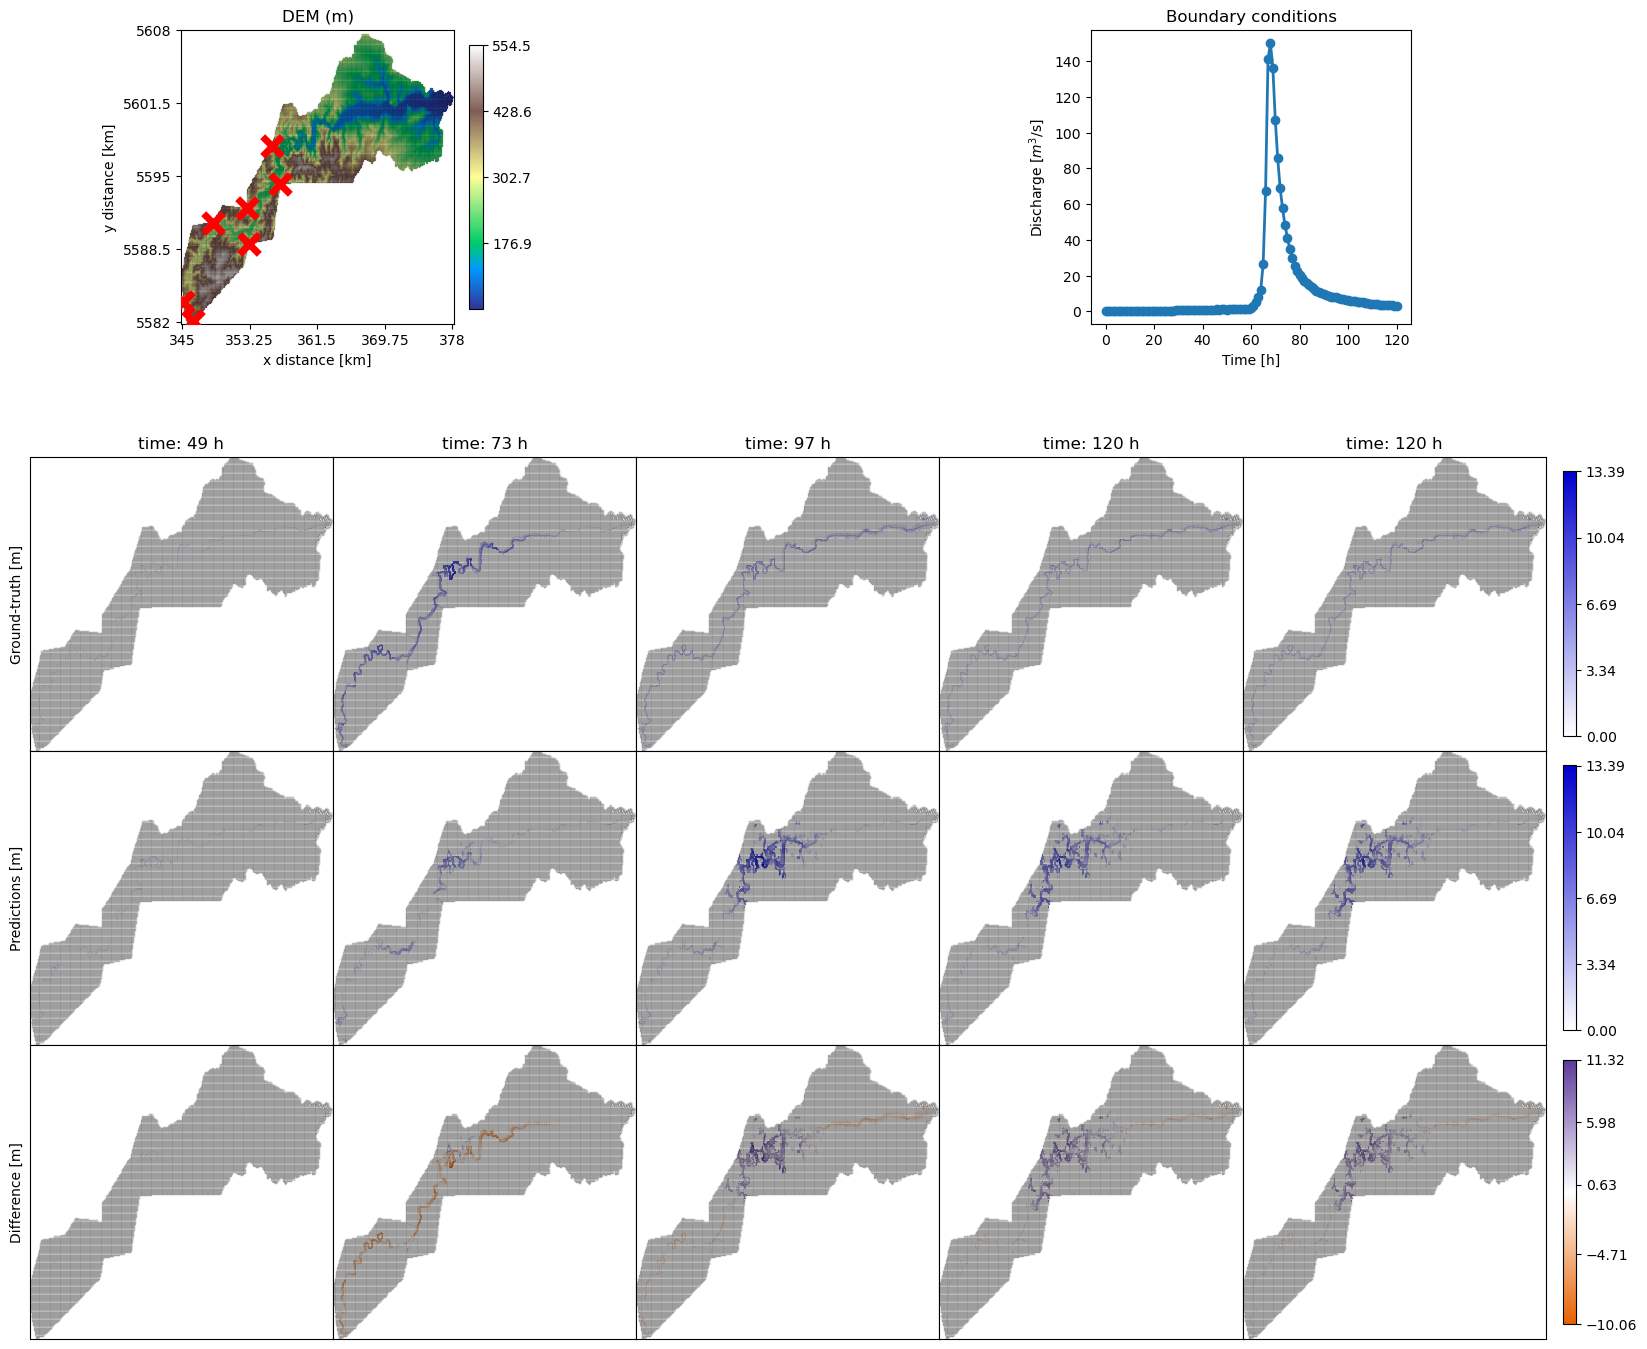

--- bcaugment_only_bestCSI_bothbanks_dz10m ---


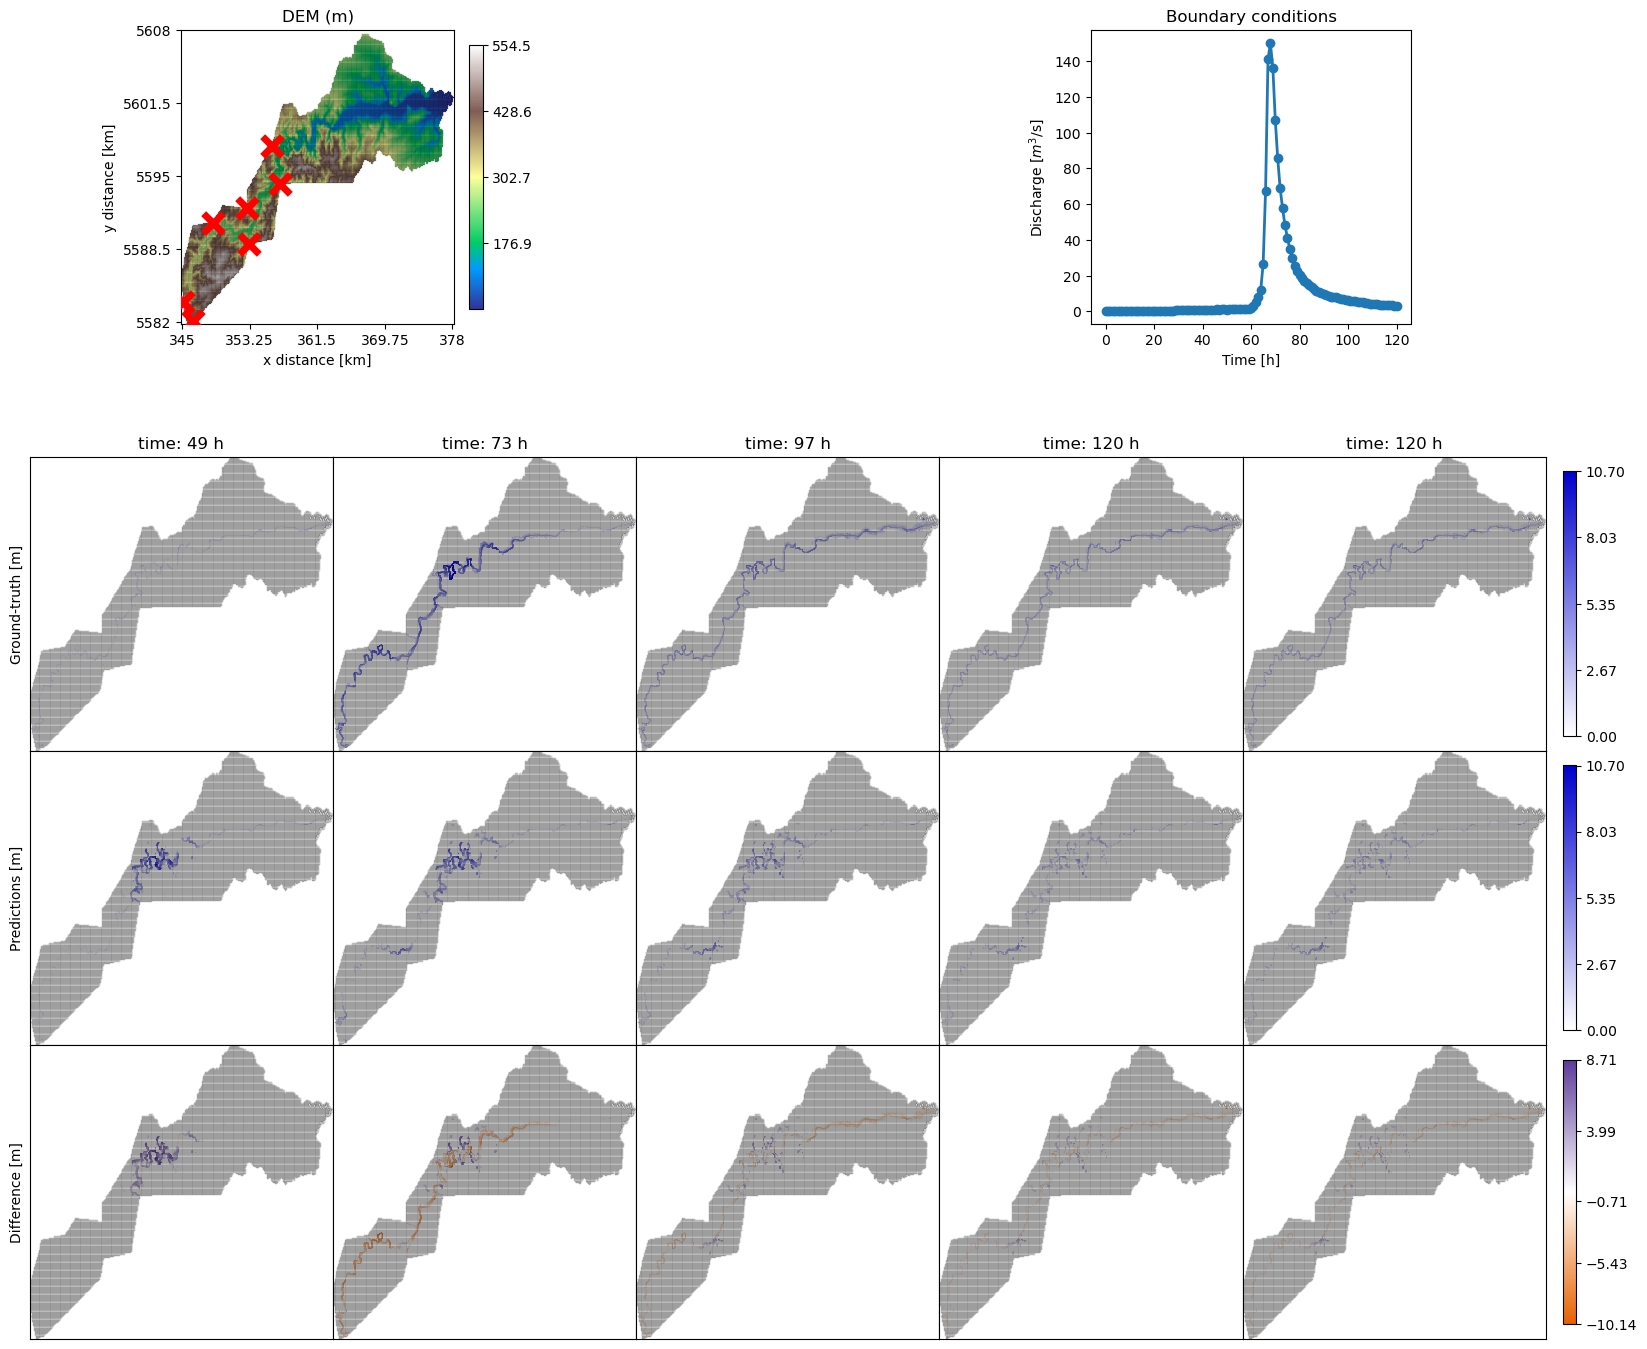

--- bcaugment_only_best_valloss_gap_dz5m ---


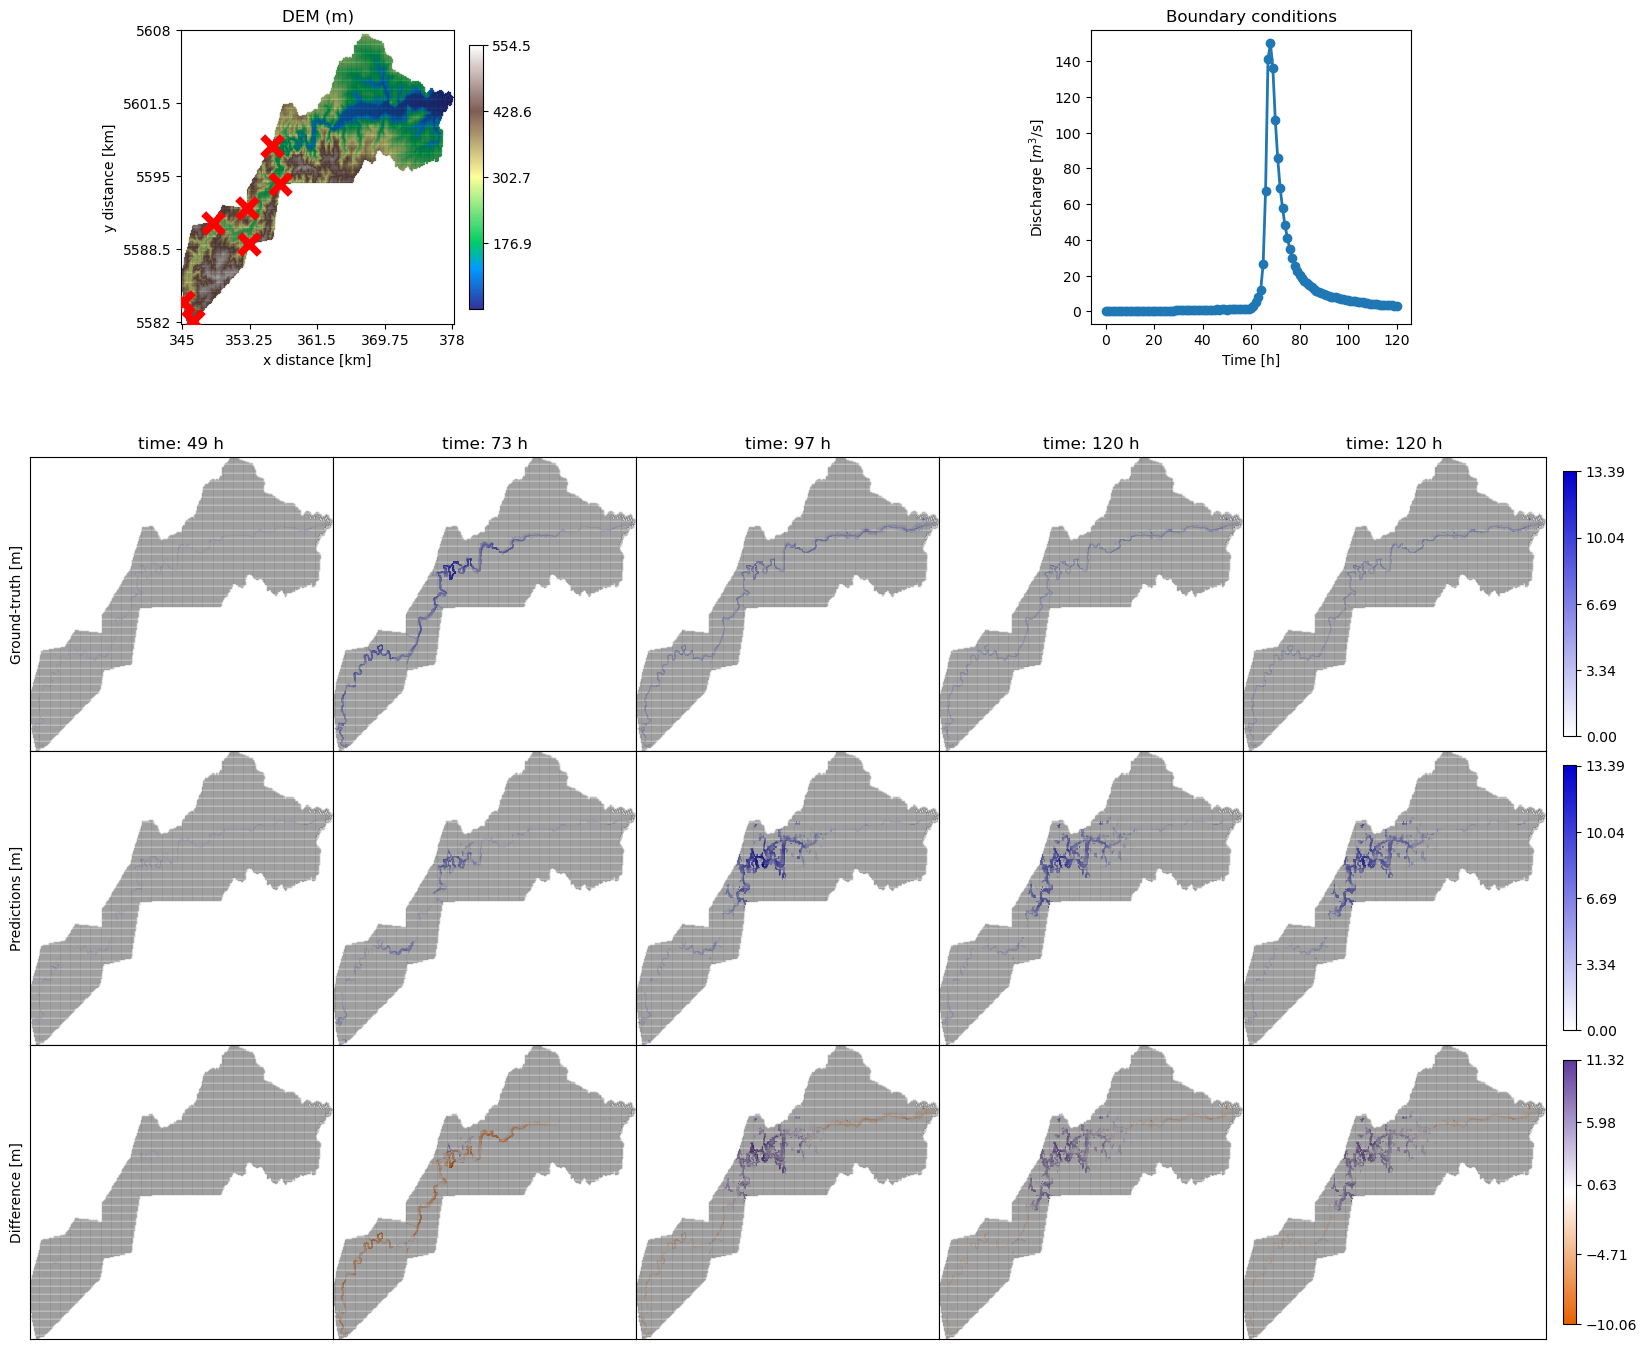

--- bcaugment_only_bestCSI_gap_dz5m ---


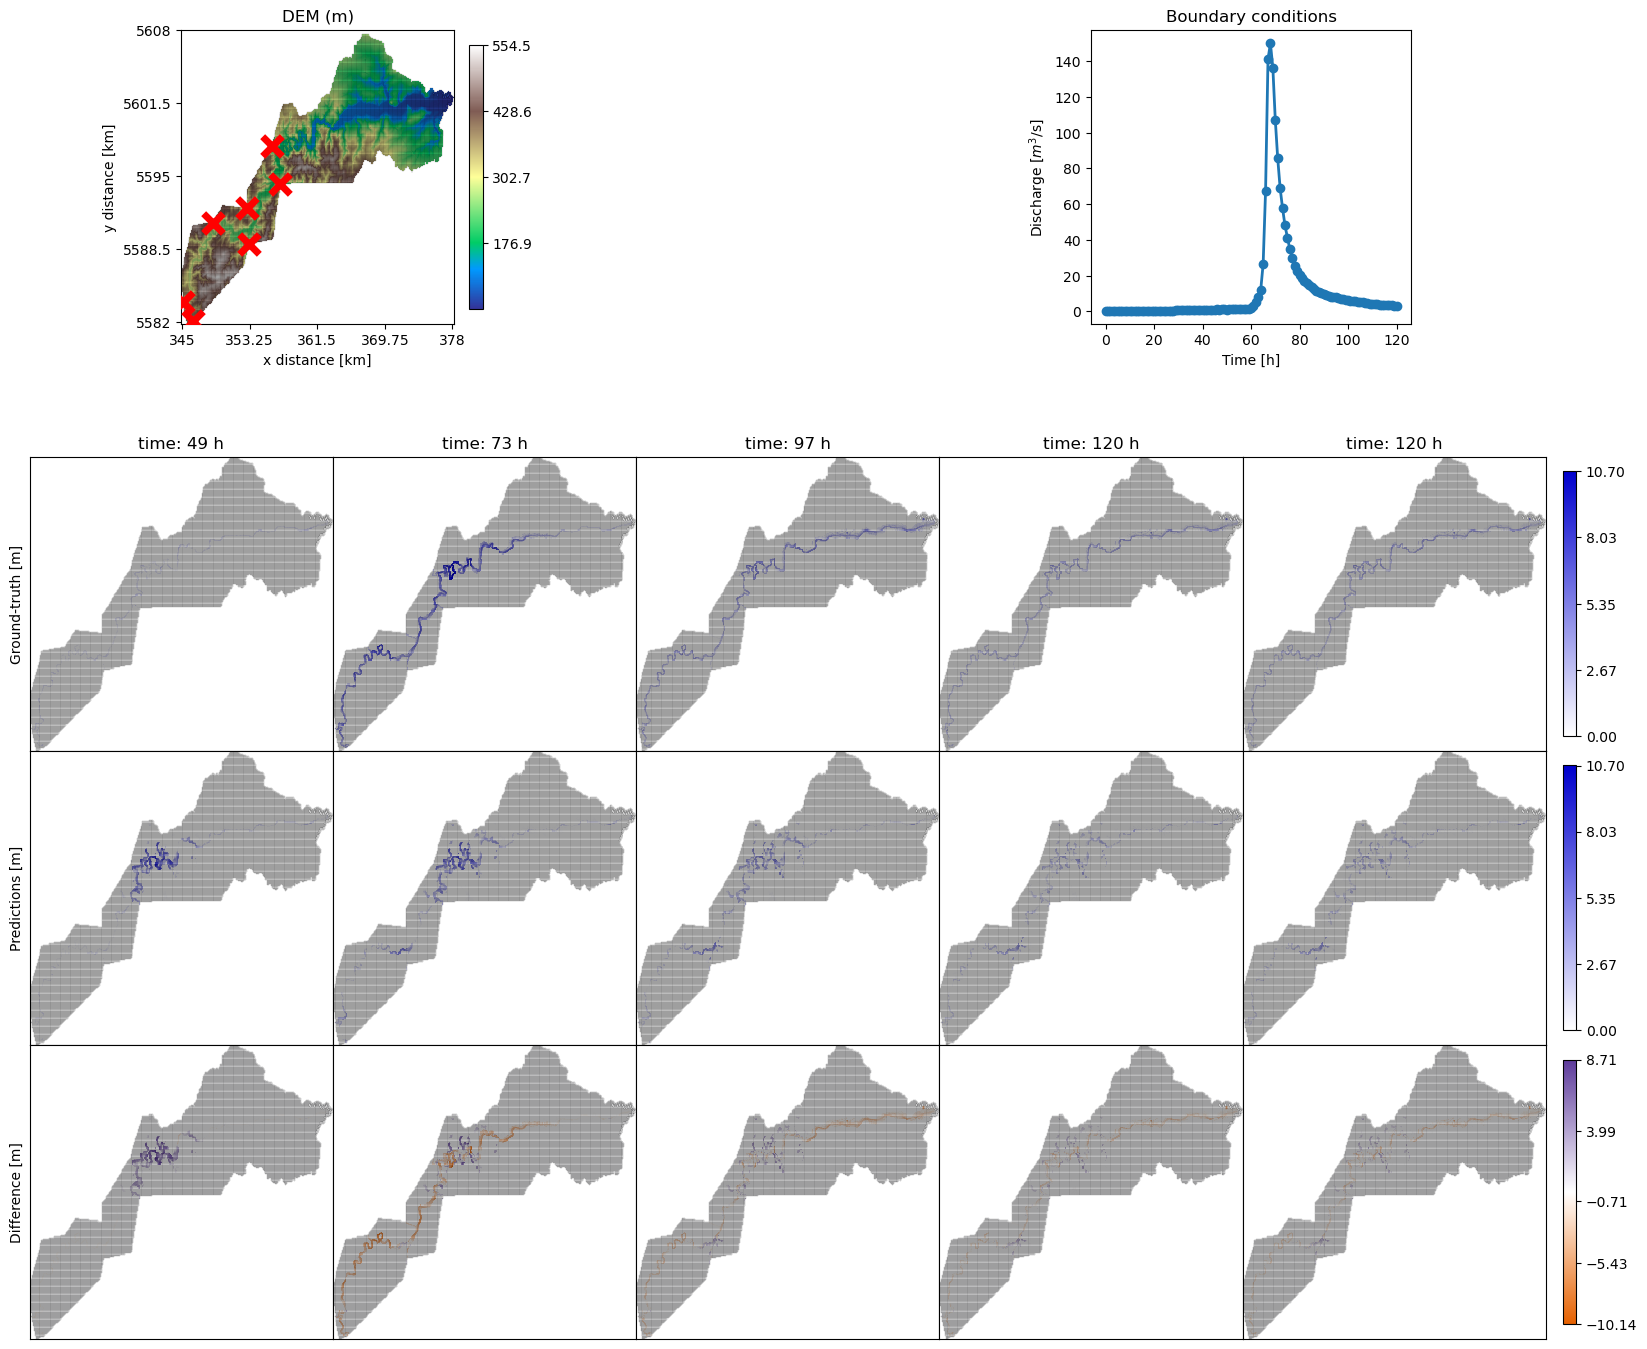

--- bcaugment_only_best_valloss_thin_dam2_dz15m ---


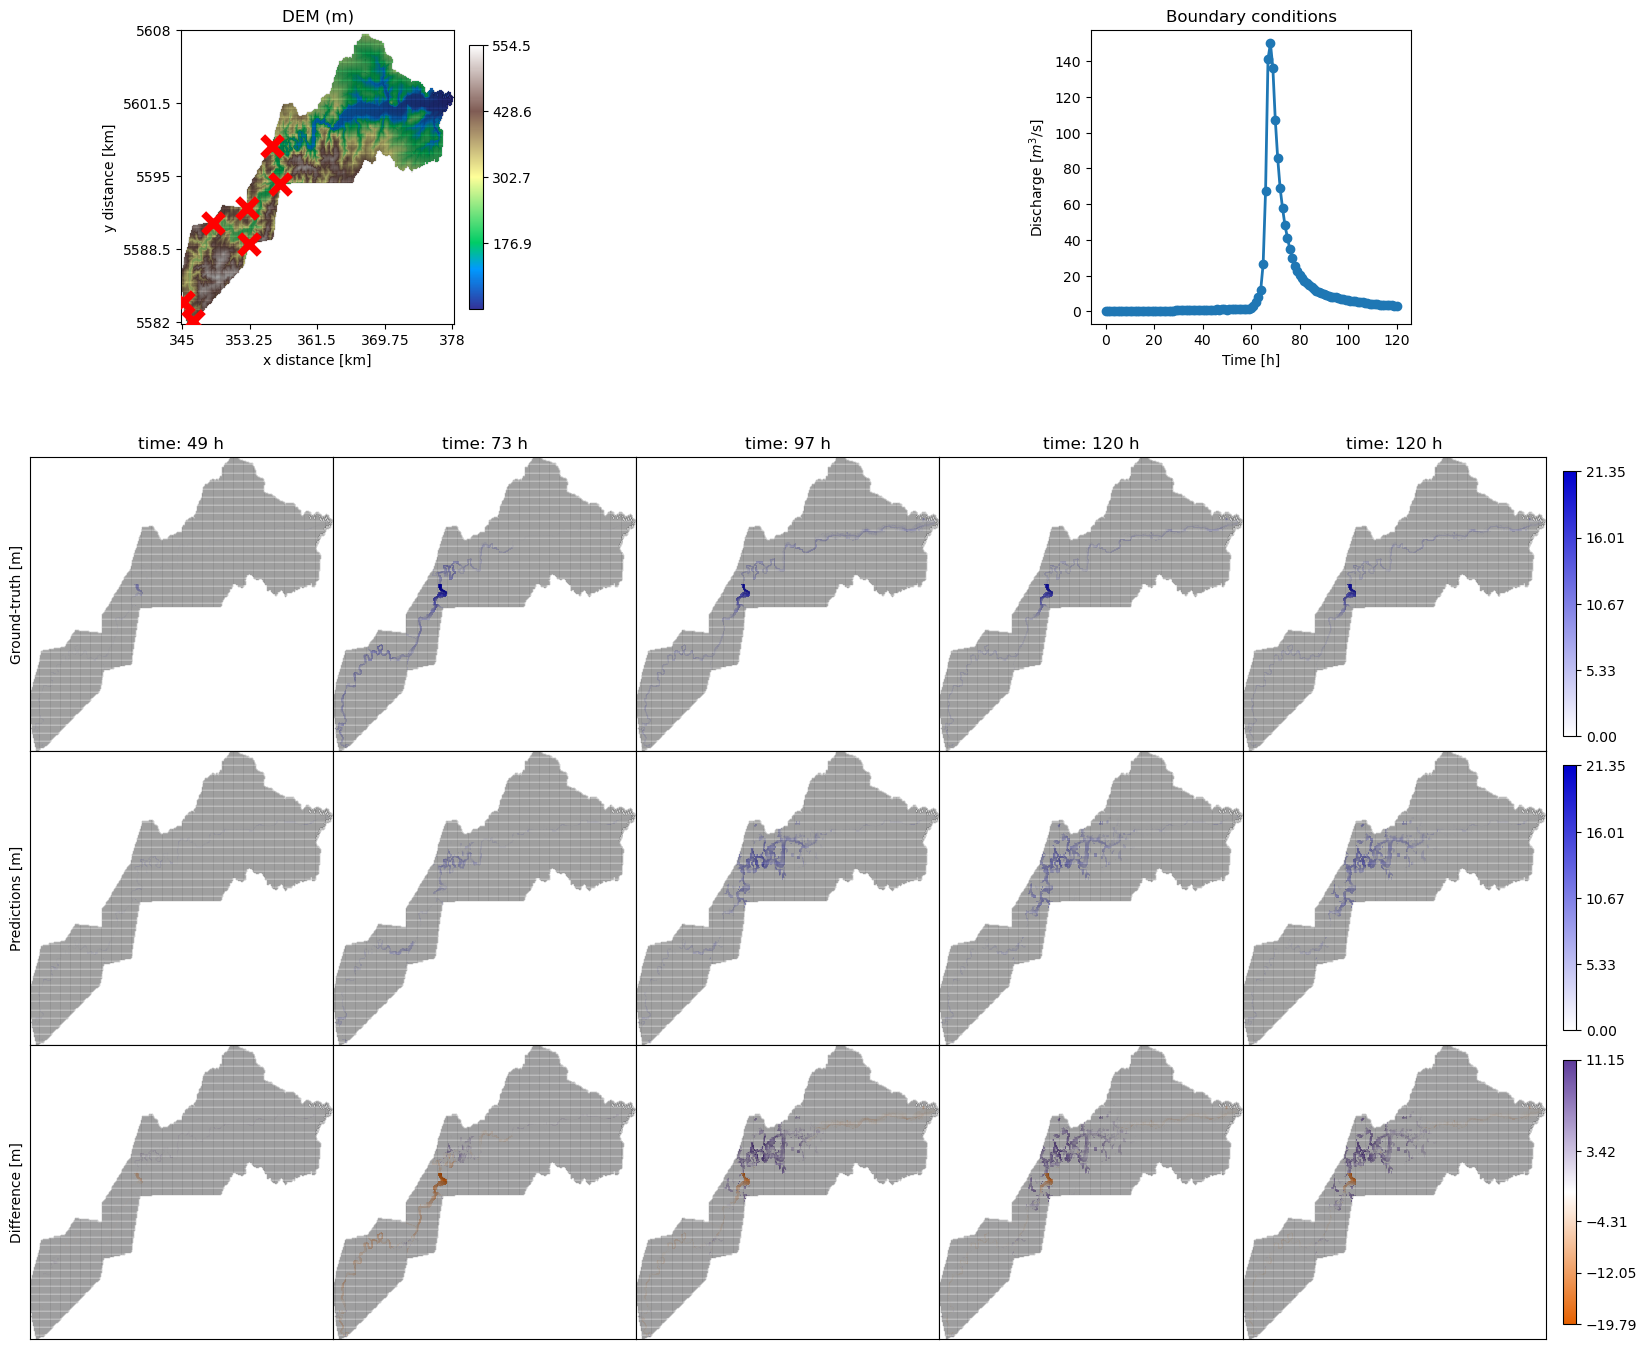

--- bcaugment_only_bestCSI_thin_dam2_dz15m ---


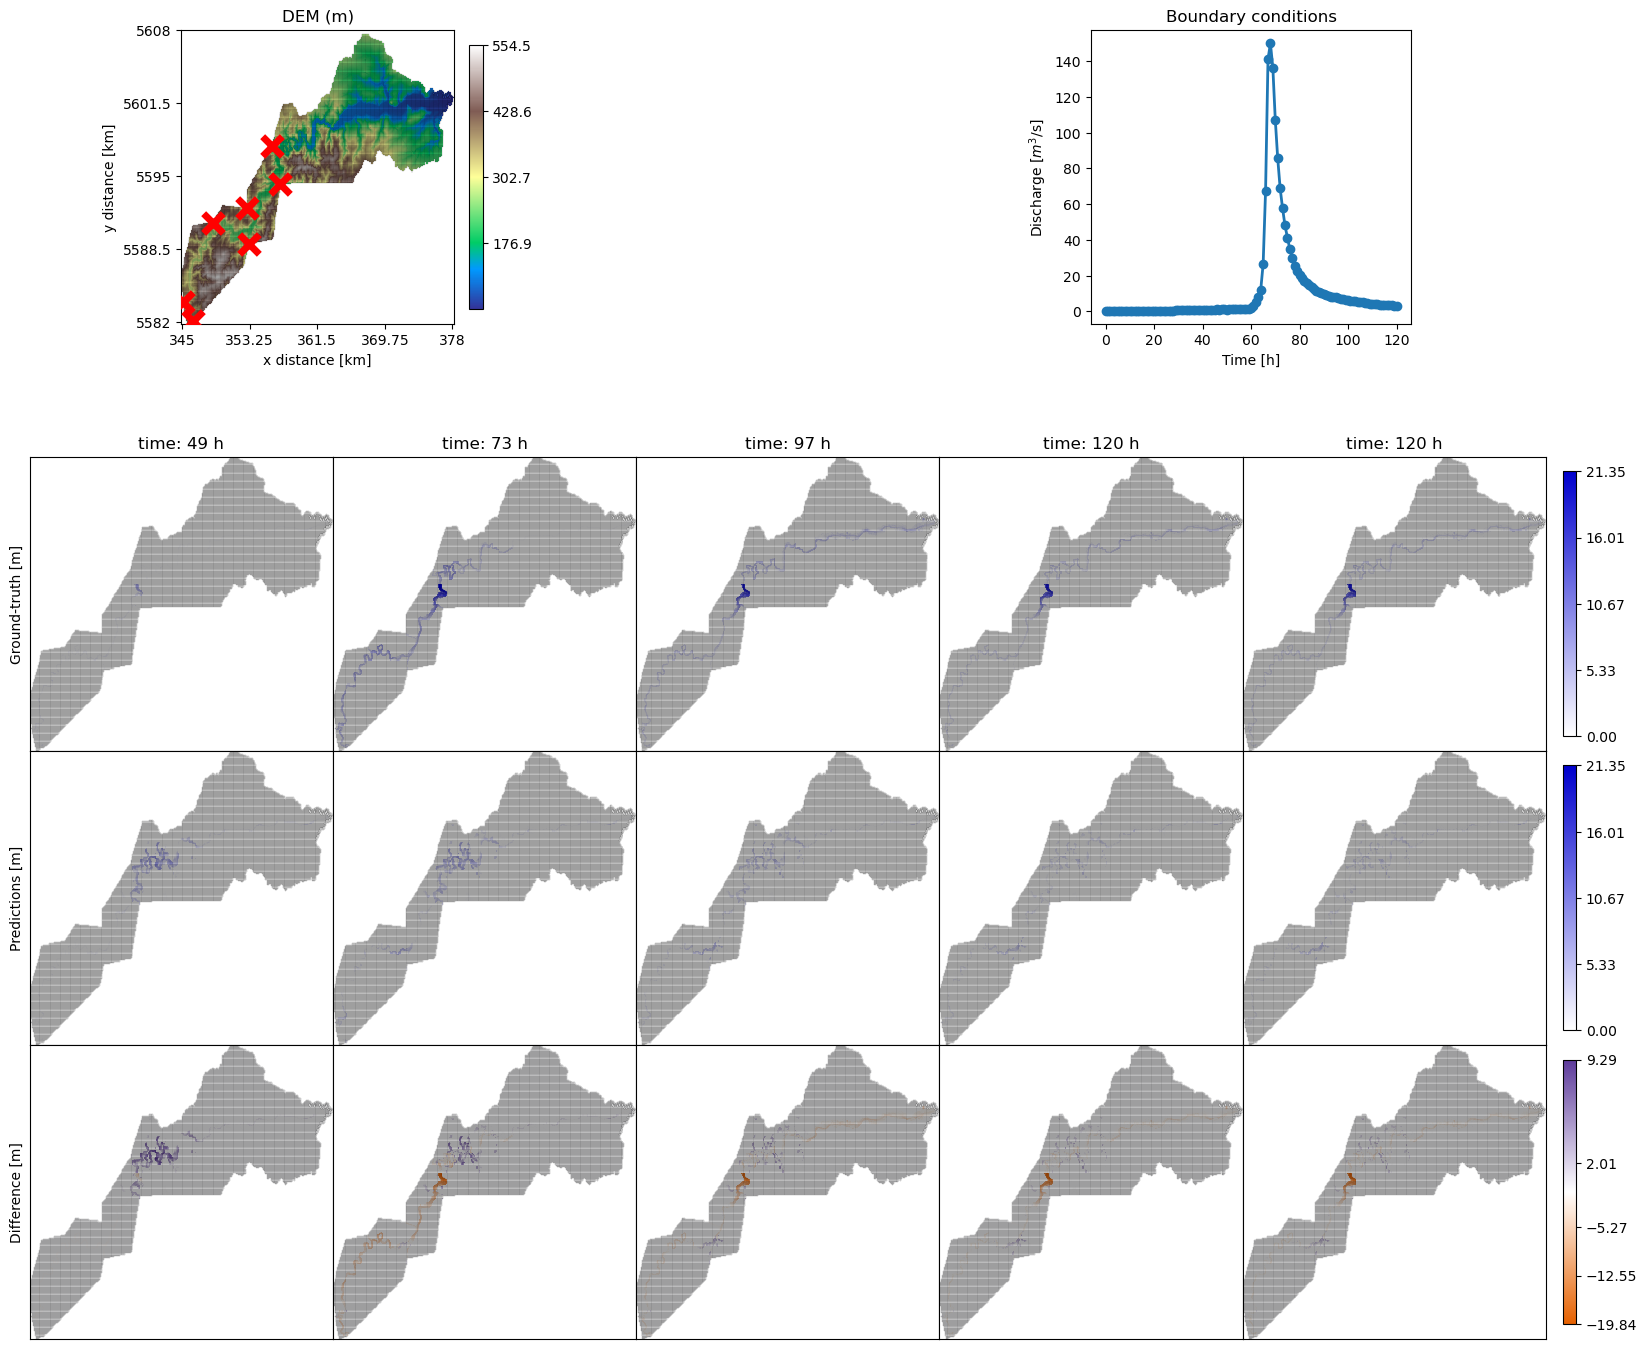

--- bcaugment_only_best_valloss_thin_dam2_dz20m ---


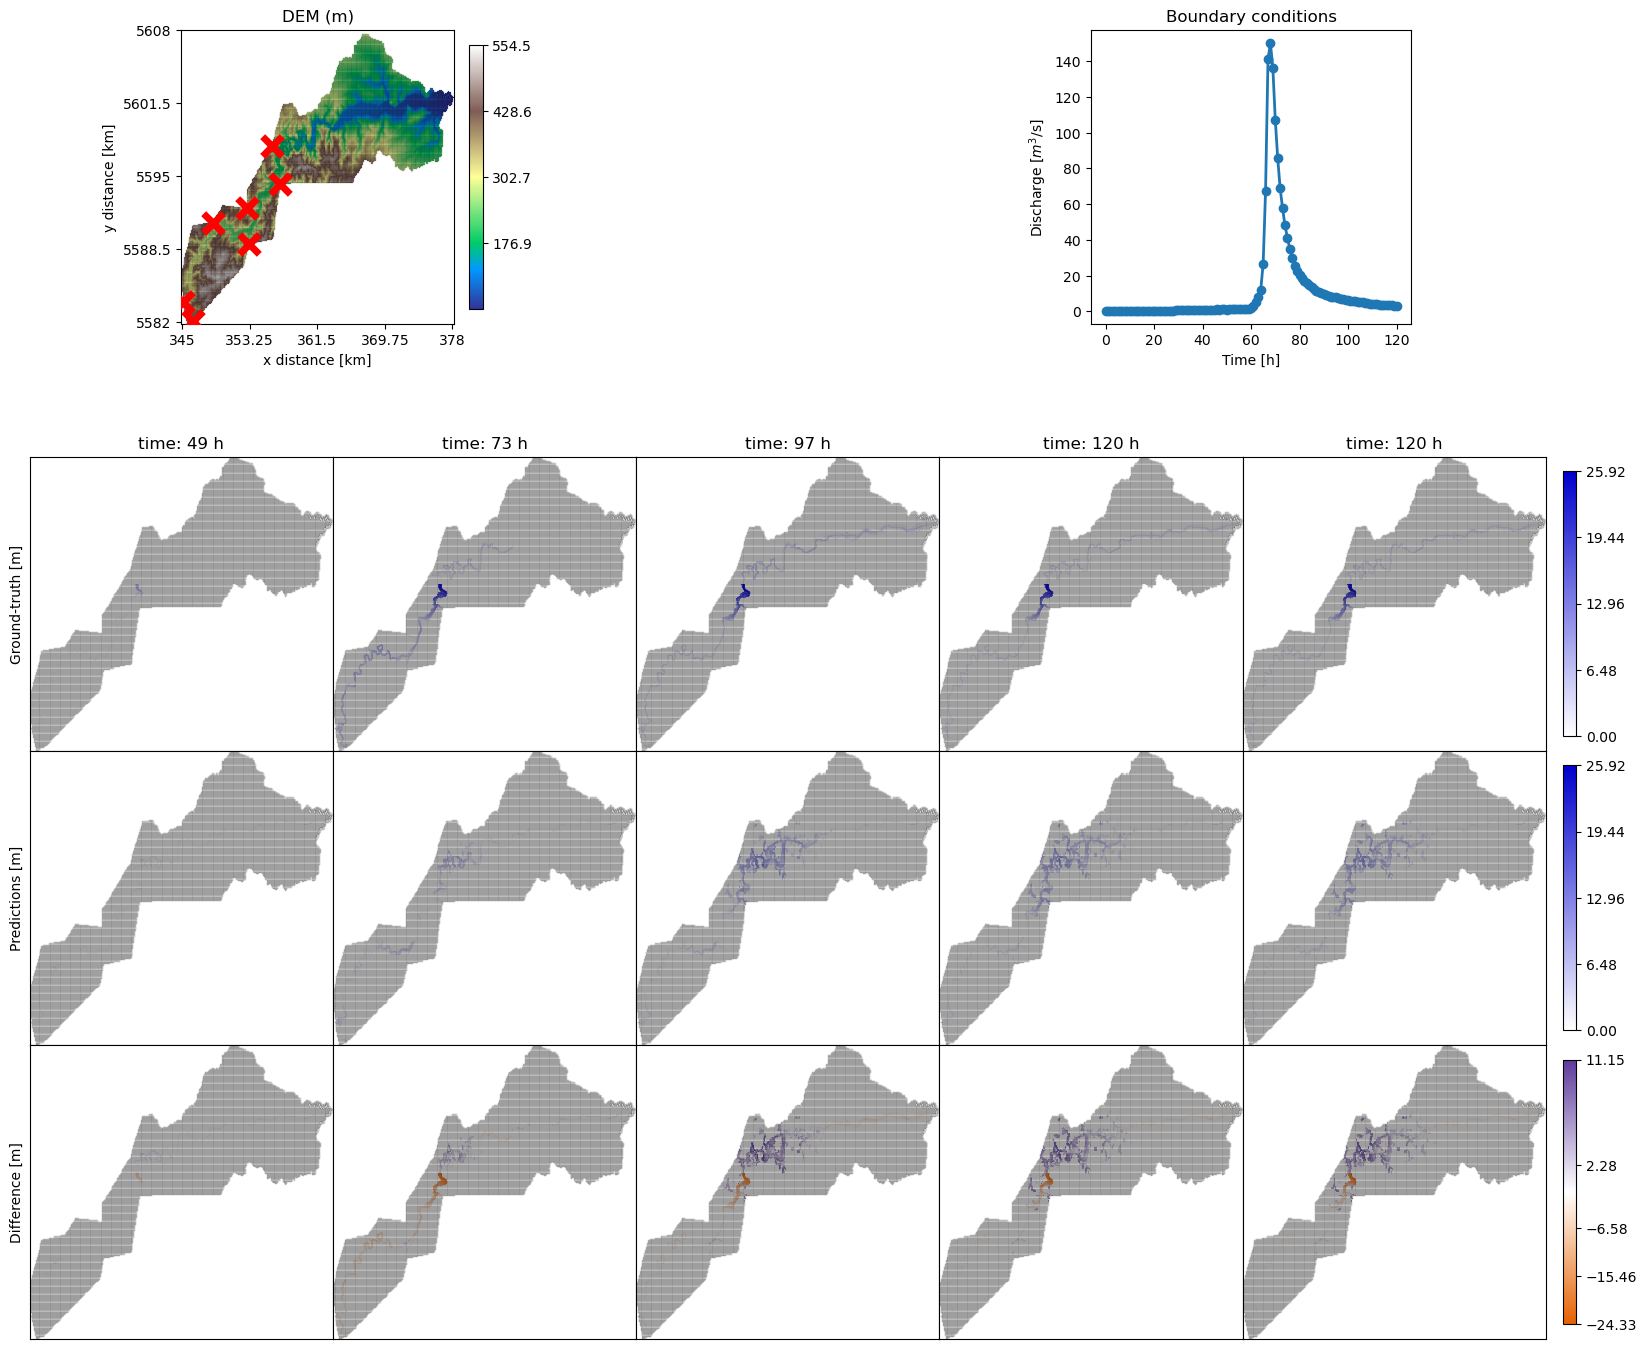

--- bcaugment_only_bestCSI_thin_dam2_dz20m ---


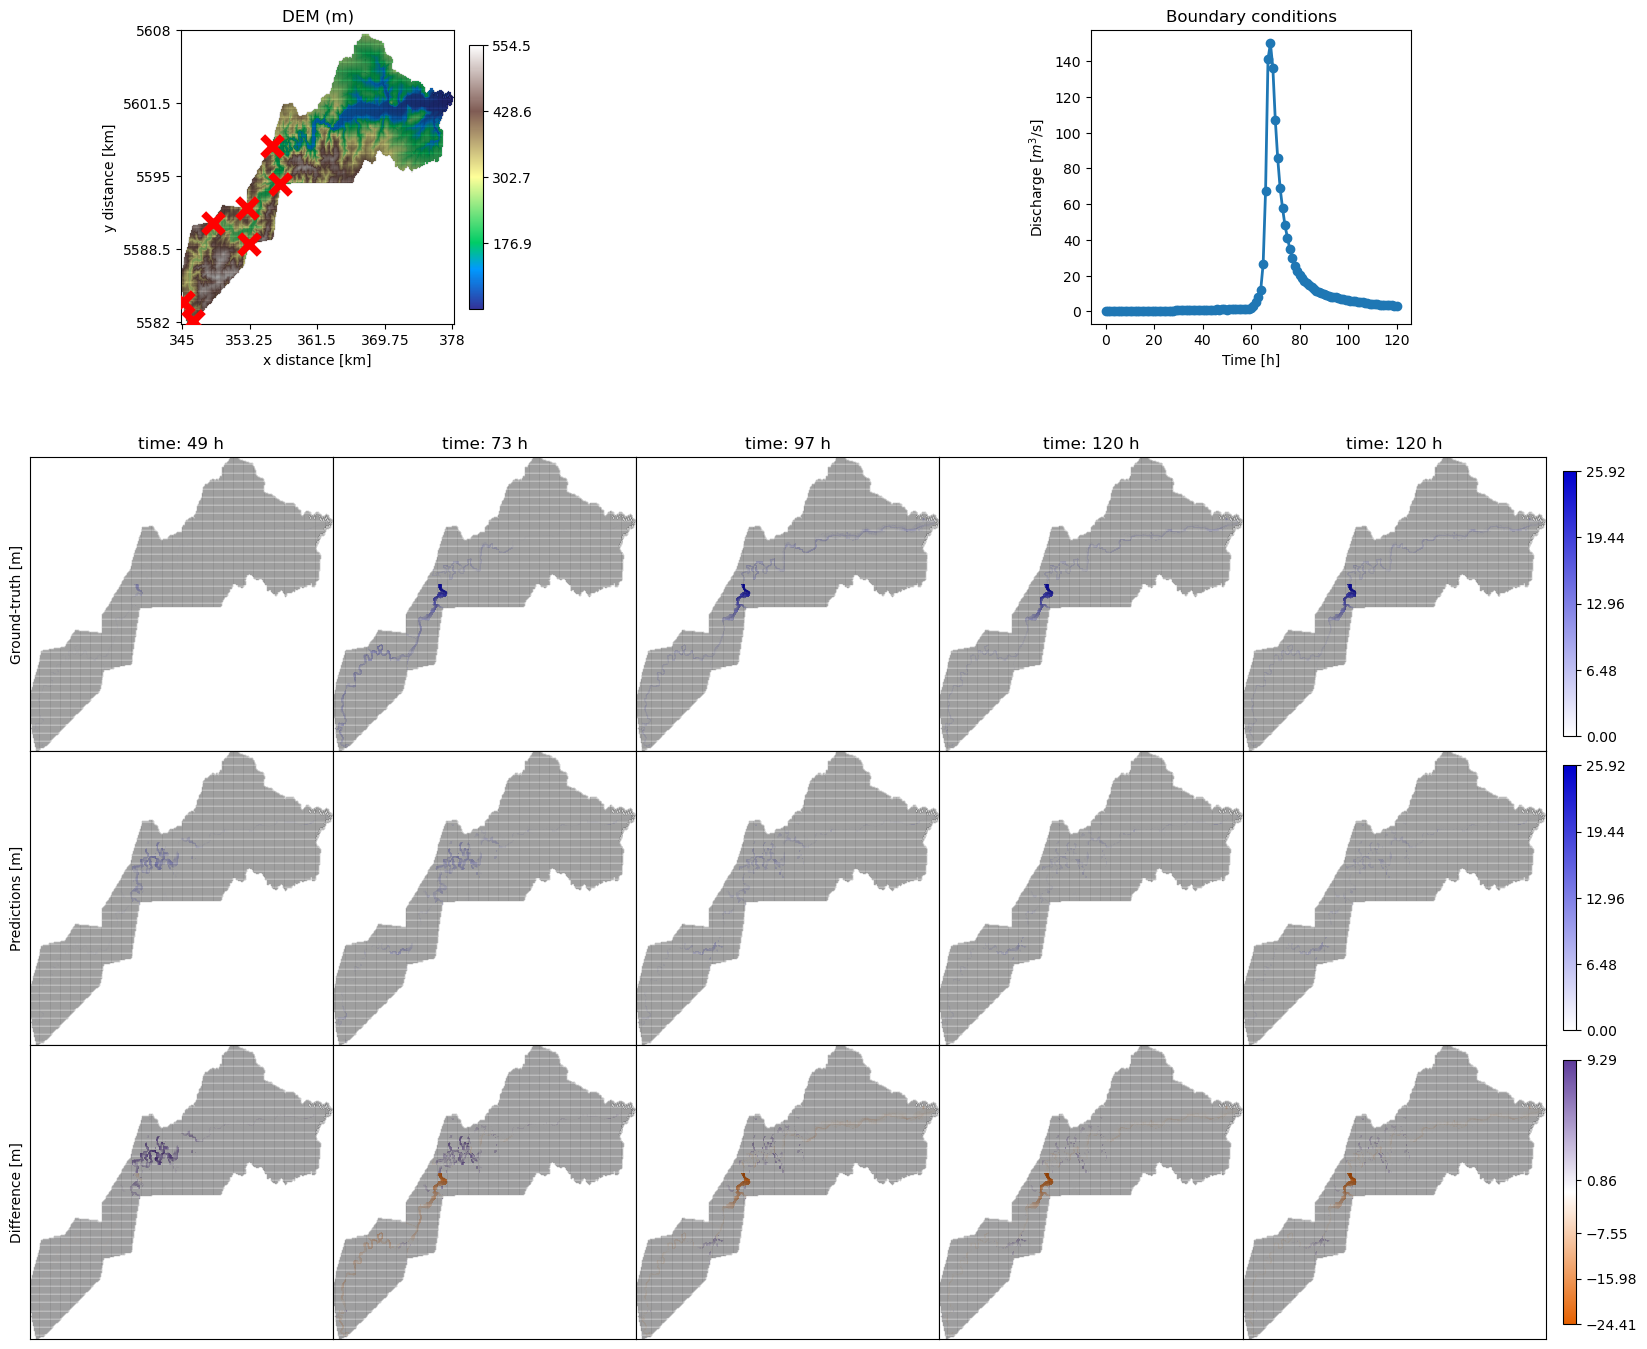

In [ ]:
for (tag, name), r in results.items():
    print(f'--- {name}--{tag} ---')
    n_steps = r['plot_rollout'].real_rollout.shape[-1]
    plot_times = [48, 72, 96, n_steps - 1]
    r['plot_rollout'].compare_h_rollout(plot_times=plot_times, scale=0)
    plt.show()

## CSI vs threshold, per scenario

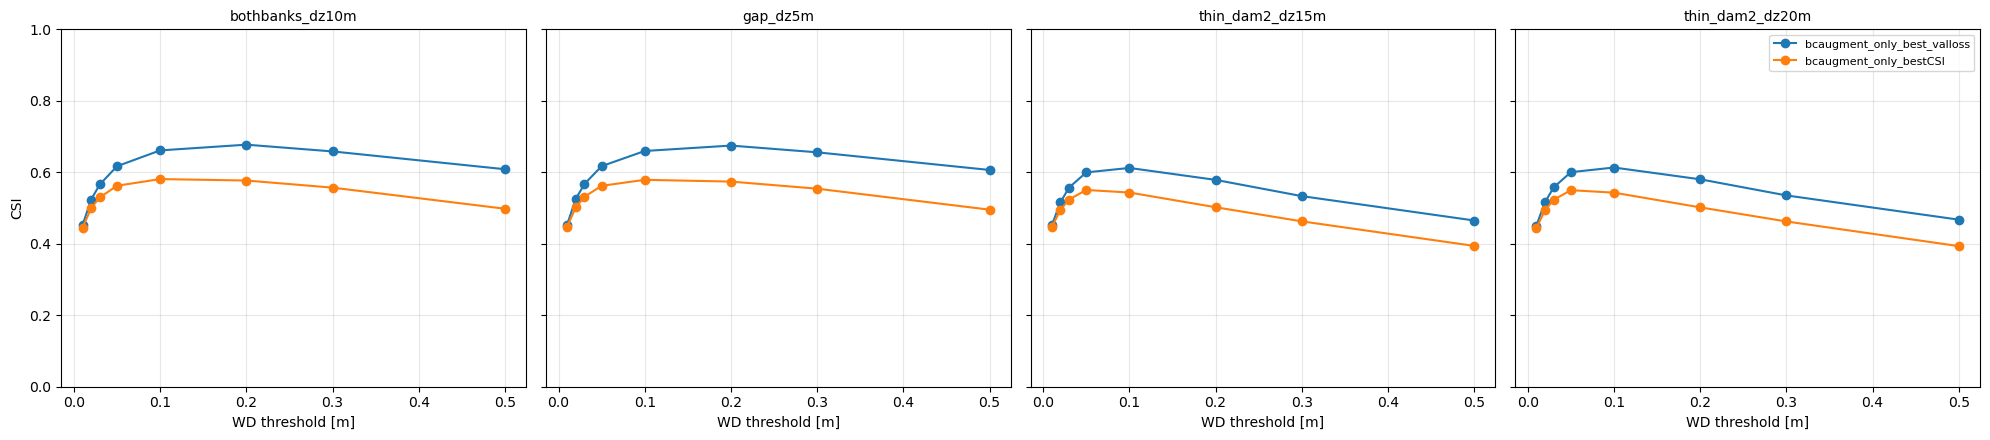

In [ ]:
thresholds = [0.01, 0.02, 0.03, 0.05, 0.10, 0.20, 0.30, 0.50]

fig, axes = plt.subplots(1, len(TEST_SCENARIOS), figsize=(5 * len(TEST_SCENARIOS), 4.5), sharey=True)
for ax, tag in zip(axes, TEST_SCENARIOS):
    for m in MODELS:
        key = (tag, m['name'])
        if key not in results:
            continue
        pr = results[key]['plot_rollout']
        curve = [pr._get_CSI(water_threshold=t).nanmean().item() for t in thresholds]
        ax.plot(thresholds, curve, 'o-', label=m['name'])
    ax.set_title(tag, fontsize=10)
    ax.set_xlabel('WD threshold [m]')
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel('CSI')
axes[-1].legend(fontsize=8)
plt.tight_layout()
plt.show()

## Spatial TP / FP / FN maps — structures model vs bcaugment-only, final timestep
Red = false alarm (predicted wet, actually dry), orange = miss (predicted dry, actually wet).

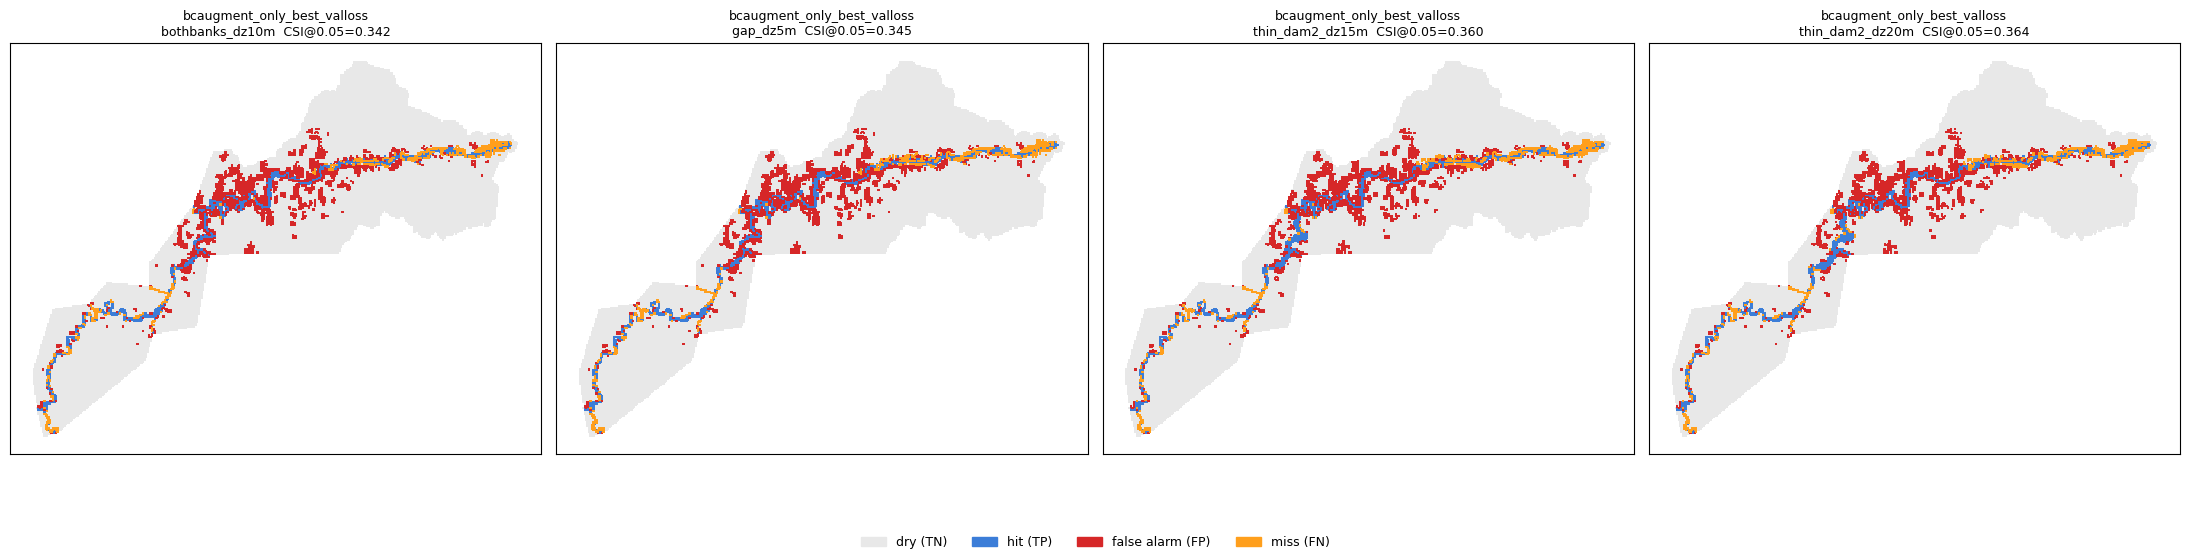

In [ ]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

THR = 0.05
MODELS_FOR_MAPS = ['structures_best_valloss', 'bcaugment_only_best_valloss']
cat_cmap = ListedColormap(['#e8e8e8', '#3b7dd8', '#d62728', '#ff9f1c'])  # TN, TP, FP, FN
legend_handles = [Patch(color=c, label=l) for c, l in zip(
    cat_cmap.colors, ['dry (TN)', 'hit (TP)', 'false alarm (FP)', 'miss (FN)'])]

fig, axes = plt.subplots(len(MODELS_FOR_MAPS), len(TEST_SCENARIOS),
                          figsize=(5.5 * len(TEST_SCENARIOS), 5.5 * len(MODELS_FOR_MAPS)))
for row, model_name in enumerate(MODELS_FOR_MAPS):
    for col, tag in enumerate(TEST_SCENARIOS):
        ax = axes[row, col]
        key = (tag, model_name)
        if key not in results:
            ax.set_visible(False)
            continue
        r = results[key]
        pr = r['plot_rollout']
        pred = pr._predicted_rollout_s0[:, 0, :].cpu().numpy()
        real = pr._real_rollout_s0[:, 0, :].cpu().numpy()
        t = -1
        p, g = pred[:, t] > THR, real[:, t] > THR
        n_s0 = pred.shape[0]
        pos_s0 = np.asarray(pr.pos)[:n_s0]  # PlotRollout stores pos = dataset.mesh.face_xy directly

        cat = np.zeros(n_s0, dtype=int)
        cat[p & g] = 1
        cat[p & ~g] = 2
        cat[~p & g] = 3
        order = np.argsort(cat, kind='stable')
        csi_t = (p & g).sum() / max((p | g).sum(), 1)
        ax.scatter(pos_s0[order, 0], pos_s0[order, 1], c=cat[order], cmap=cat_cmap,
                   vmin=0, vmax=3, s=3, marker='s', linewidths=0)
        ax.set_title(f'{model_name}\n{tag}  CSI@0.05={csi_t:.3f}', fontsize=9)
        ax.set_aspect('equal')
        ax.set_xticks([]); ax.set_yticks([])
fig.legend(handles=legend_handles, loc='lower center', ncol=4, fontsize=9, frameon=False)
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

## In-training-set sanity check: the trained thin-dam crossing (`thin_dam`, not the held-out `thin_dam2`)

`thin_dam_dz15m` / `thin_dam_dz20m` are 2 of the 12 structure scenarios the `structures_*` models
actually trained on - not a held-out generalization test. `bcaugment_only_*` never saw any structure
at all, so it's shown here purely for contrast, not as a fair comparison. If the structures model's
training worked, it should look close to perfect on these; if it doesn't, that's a real problem with
the training itself, not a generalization gap.

In [ ]:
THIN_DAM_TRAIN_SCENARIOS = {
    'thin_dam_dz15m': ('ahr_river_v03_marg_structures_thin_dam_dz15m_additionalsrc_velocity_100m_warmstart',
                        'in-training-set (trained crossing, dz15m)'),
    'thin_dam_dz20m': ('ahr_river_v03_marg_structures_thin_dam_dz20m_additionalsrc_velocity_100m_warmstart',
                        'in-training-set (trained crossing, dz20m)'),
}

thin_dam_results = {}
for tag, (dataset_name, desc) in THIN_DAM_TRAIN_SCENARIOS.items():
    print(f'\n=== {tag} ({desc}) ===')

    for m in MODELS:
        name, ckpt_path, config_path = m['name'], m['checkpoint'], m['config']
        if not os.path.exists(ckpt_path):
            print(f'  [skip] {name}: checkpoint not found')
            continue

        # Same pattern as the main eval loop above - own config per model, only
        # test_dataset_name overridden, train_dataset_name stays the model's own
        # true training set so scalers are correct.
        cache_key = (config_path, tag)
        if cache_key not in _dataset_cache:
            cfg_s = read_config(config_path)
            cfg_s['dataset_parameters']['test_dataset_name'] = dataset_name

            wandb.init(mode='disabled', project='mswe-gnn', config=cfg_s, reinit=True)
            fix_dict_in_config(wandb)
            config_s = wandb.config

            _, _, test_dataset, scalers = create_model_dataset(
                scalers=config_s.scalers, device=device,
                **config_s.dataset_parameters,
                **config_s.selected_node_features,
                **config_s.selected_edge_features,
            )
            temporal_test_dataset_parameters = get_temporal_test_dataset_parameters(
                config_s, config_s.temporal_dataset_parameters
            )
            temporal_test_dataset = to_temporal_dataset(test_dataset, rollout_steps=-1, **temporal_test_dataset_parameters)
            num_node_features = temporal_test_dataset[0].x.size(-1)
            num_edge_features = temporal_test_dataset[0].edge_attr.size(-1)

            _dataset_cache[cache_key] = (
                cfg_s, test_dataset, scalers, temporal_test_dataset_parameters,
                num_node_features, num_edge_features,
            )

        (cfg_s, test_dataset, scalers, temporal_test_dataset_parameters,
         num_node_features, num_edge_features) = _dataset_cache[cache_key]

        model, hid, K_list = load_model_from_checkpoint(
            ckpt_path, dict(cfg_s),
            num_node_features=num_node_features, num_edge_features=num_edge_features,
            previous_t=temporal_test_dataset_parameters['previous_t'],
            num_scales=test_dataset[0].mesh.num_meshes, device=device,
        )

        plot_rollout = PlotRollout(
            model, test_dataset[0], scalers=scalers,
            warmup_steps=0, **temporal_test_dataset_parameters
        )

        rollout_loss = plot_rollout._get_rollout_loss(type_loss='RMSE')
        loss_mean = rollout_loss.mean(0)
        rmse_wd = loss_mean[0].item() if loss_mean.ndim > 0 else loss_mean.item()
        csi_005 = plot_rollout._get_CSI(water_threshold=0.05).nanmean().item()
        csi_03 = plot_rollout._get_CSI(water_threshold=0.30).nanmean().item()

        thin_dam_results[(tag, name)] = {
            'desc': desc, 'hid_features': hid, 'K': K_list,
            'rmse_wd': rmse_wd, 'csi_005': csi_005, 'csi_03': csi_03,
            'plot_rollout': plot_rollout,
        }
        print(f'  {name:<24} hid={hid} K={K_list}  RMSE_WD={rmse_wd:.4f}  CSI@0.05={csi_005:.4f}  CSI@0.30={csi_03:.4f}')

thin_dam_summary = pd.DataFrame([
    {'scenario': tag, 'model': name, 'RMSE_WD': r['rmse_wd'], 'CSI@0.05': r['csi_005'], 'CSI@0.30': r['csi_03']}
    for (tag, name), r in thin_dam_results.items()
]).sort_values(['scenario', 'model']).reset_index(drop=True)
thin_dam_summary

In [ ]:
for (tag, name), r in thin_dam_results.items():
    print(f'--- {name} -- {tag} ---')
    n_steps = r['plot_rollout'].real_rollout.shape[-1]
    plot_times = [48, 72, 96, n_steps - 1]
    r['plot_rollout'].compare_h_rollout(plot_times=plot_times, scale=0)
    plt.show()